#UCI Heart Disease (Cleveland)

**Heart disease Preprocessing Pipeline**

In [17]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
columns = ["age","sex","cp","trestbps","chol","fbs","restecg",
           "thalach","exang","oldpeak","slope","ca","thal","target"]
df = pd.read_csv("processed.cleveland.data", names=columns)
print("Shape:", df.shape)

df.head()

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [10]:
df.dtypes

,0
age,float64
sex,float64
cp,float64
trestbps,float64
chol,float64
fbs,float64
restecg,float64
thalach,float64
exang,float64
oldpeak,float64


In [11]:
df.replace('?', np.nan, inplace=True)
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [12]:
df = df.dropna()
print("new shape:", df.shape)

new shape: (297, 14)


Since binary classification so converting target column into a binary column<br>
heart disease present (1) vs absent (0)

In [14]:
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

In [15]:
counts = df['target'].value_counts()
percent = df['target'].value_counts(normalize=True) * 100

print("Counts:\n", counts)
print("\nPercentage:\n", percent)

Counts:
 target
0    160
1    137
Name: count, dtype: int64

Percentage:
 target
0    53.872054
1    46.127946
Name: proportion, dtype: float64


The dataset is relatively balanced, as both classes are nearly equally represented. There is no severe skew toward either class, which means the model is unlikely to be biased heavily toward one class during training.


---



Since the imbalance is minor, applying Synthetic Minority Over-sampling Technique (SMOTE) is not necessary, as it could artificially introduce synthetic samples and potentially distort the natural distribution of clinical data.

Instead, class weighting is more appropriate because:

It preserves the original dataset distribution
It avoids introducing synthetic data
It is computationally efficient
It is well-suited for small to moderate imbalance

corr matrix

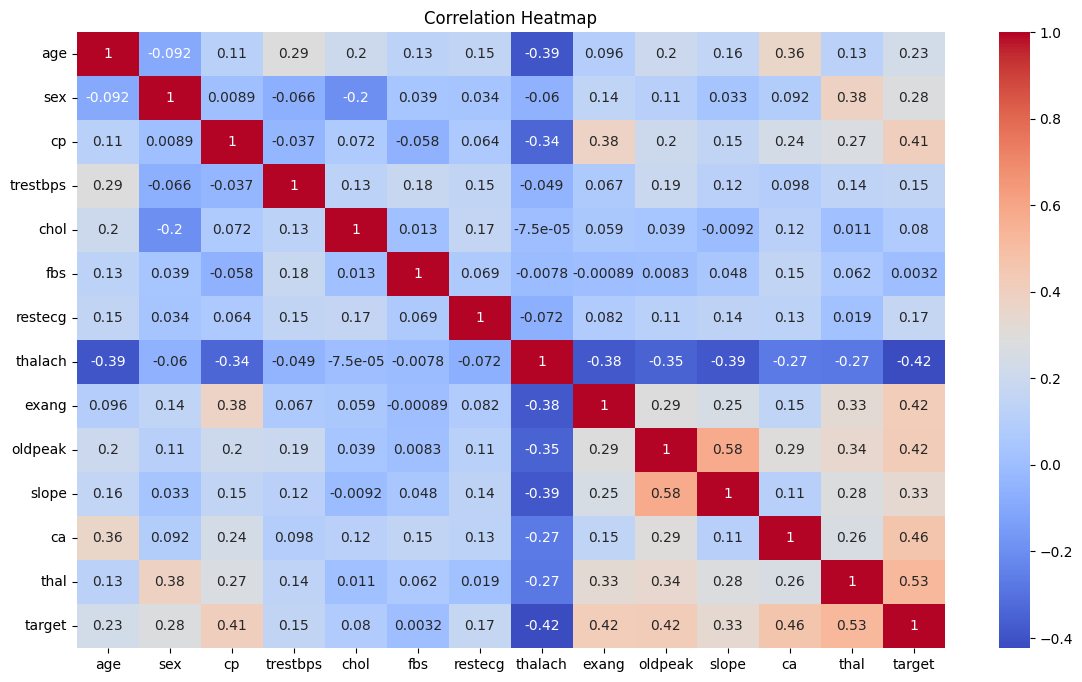

In [19]:
plt.figure(figsize=(14,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Train test split

In [20]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape, X_test.shape)

(237, 13) (60, 13)


OHE on categorical cols

In [21]:
cat_cols = ["cp","restecg","slope","thal"]

X_train = pd.get_dummies(X_train, columns=cat_cols)
X_test = pd.get_dummies(X_test, columns=cat_cols)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

standard scaling on continuous/numerical cols

In [22]:
num_cols = ["age","trestbps","chol","thalach","oldpeak","ca"]

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

class weights

In [23]:
classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
class_weights = dict(zip(classes, weights))
print(class_weights)

{np.int64(0): np.float64(0.92578125), np.int64(1): np.float64(1.0871559633027523)}


In [25]:
import joblib

In [26]:
joblib.dump(X_train, "X_train.pkl")
joblib.dump(X_test, "X_test.pkl")
joblib.dump(y_train, "y_train.pkl")
joblib.dump(y_test, "y_test.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(class_weights, "class_weights.pkl")

['class_weights.pkl']